# Customer Segmentation with K-Means Clustering

**The problem, in plain English**
A shopping mall has data on 200 customers but no labels like "good customer" or "bad customer". The marketing team wants to know: **are there natural groups of customers**, so each group can get a different offer?

This is **clustering**, a type of **unsupervised learning**: there is no "right answer" column to predict. The algorithm looks only at the features and groups customers who look similar to each other.

**What I do in this notebook**
1. Load and explore the data → 2. Scale the features → 3. Decide how many groups (k) using the elbow method and silhouette score → 4. Run K-Means → 5. Describe each segment and suggest an action for it → 6. Check that the result is stable (different seeds, a different algorithm) → 7. Assign new customers to a segment

> **About the data:** the public *Mall Customers* practice dataset (200 customers: gender, age, annual income in thousands of dollars, and a "spending score" from 1 to 100 assigned by the mall). How it was collected is not documented, and it is widely used as a teaching dataset, so treat it as a learning dataset rather than real business data.

## Step 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")
SEED = 42

## Step 2 — Load the data

Each row is one customer.

| Column | Meaning |
|---|---|
| `Gender`, `Age` | Customer background |
| `income` | Annual income in thousands of dollars |
| `score` | Spending score (1–100) assigned by the mall; higher = spends more |
| `CustomerID` | Just an ID, no information |

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df = df.rename(columns={"Annual Income (k$)": "income", "Spending Score (1-100)": "score"})
df = df.drop(columns="CustomerID")
print("Rows, columns:", df.shape)
print("Missing values:", int(df.isna().sum().sum()), "| Duplicate rows:", int(df.duplicated().sum()))
df.head()

Rows, columns: (200, 4)
Missing values: 0 | Duplicate rows: 0


,Gender,Age,income,score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## Step 3 — Explore the data

In [3]:
df[["Age", "income", "score"]].describe().round(1)

,Age,income,score
count,200.0,200.0,200.0
mean,38.8,60.6,50.2
std,14.0,26.3,25.8
min,18.0,15.0,1.0
25%,28.8,41.5,34.8
50%,36.0,61.5,50.0
75%,49.0,78.0,73.0
max,70.0,137.0,99.0


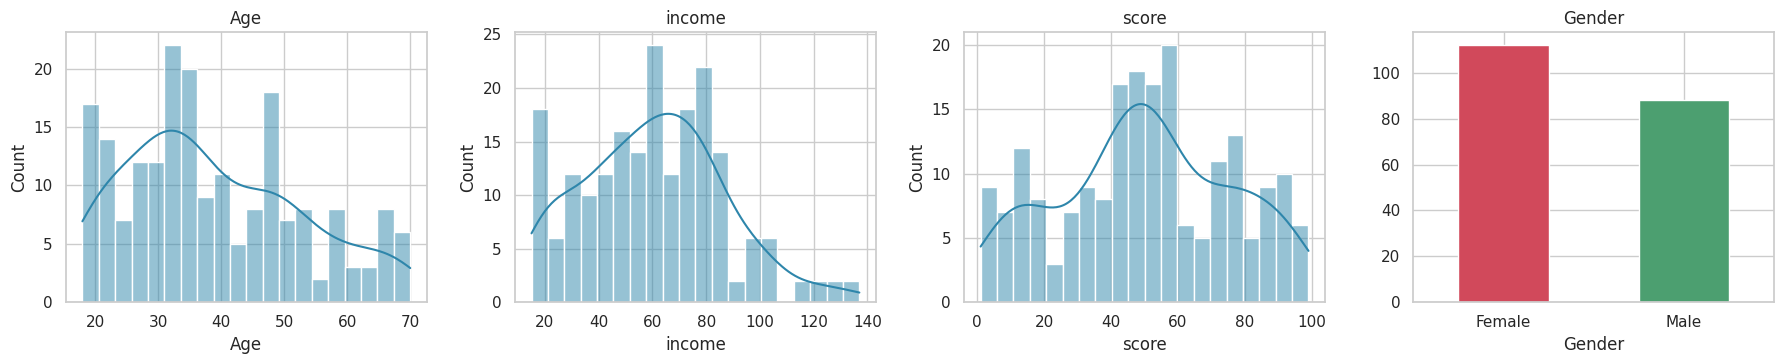

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col in zip(axes[:3], ["Age", "income", "score"]):
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color="#2E86AB"); ax.set_title(col)
df["Gender"].value_counts().plot(kind="bar", ax=axes[3], color=["#D1495B", "#4C9F70"]); axes[3].set_title("Gender"); axes[3].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Takeaway:** nothing unusual: no missing values, no extreme outliers, and a mix of ages and incomes. The more interesting question is how income and spending relate.

### Can you already *see* groups?

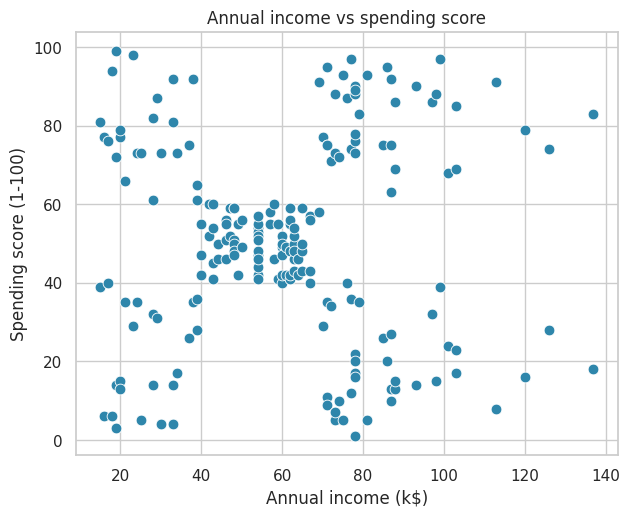

Correlation income vs score: 0.01
Correlation age vs score   : -0.33


In [5]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(data=df, x="income", y="score", s=60, color="#2E86AB")
plt.title("Annual income vs spending score"); plt.xlabel("Annual income (k$)"); plt.ylabel("Spending score (1-100)"); plt.show()

print(f"Correlation income vs score: {df['income'].corr(df['score']):.2f}")
print(f"Correlation age vs score   : {df['Age'].corr(df['score']):.2f}")

**Takeaway:** the scatter plot shows separate clumps of customers, and the correlation between income and spending score is almost zero (0.01). That is a hint that a single straight-line relationship is not the story. Instead there are **groups**, which is exactly what clustering is for. (Age and score have a mild negative correlation of -0.33.)

## Step 4 — Prepare the data: scaling

K-Means works with **distances**. If one feature has bigger numbers than another, it would dominate the distance. **Standardising** puts every feature on the same scale (mean 0, spread 1).

I cluster on **income and spending score** because those are the two business-relevant behaviour measures and they make segments easy to visualise. (Step 9 checks what happens if Age is added.)

In [6]:
features = ["income", "score"]
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
print("After scaling -> mean:", X.mean(axis=0).round(2), "| std:", X.std(axis=0).round(2))

After scaling -> mean: [-0. -0.] | std: [1. 1.]


## Step 5 — How many clusters? (the hardest question in clustering)

K-Means needs *k* (the number of groups) from us. There is no single correct answer, so I use two simple tools and then use judgement:

- **Elbow method:** *inertia* = total squared distance from each customer to its cluster centre. It always falls as k grows. We look for the **"elbow"** where adding another cluster stops helping much.
- **Silhouette score:** for each customer, how much closer they are to their own cluster than to the next nearest one. It runs from −1 to 1; **higher = better-separated clusters**.

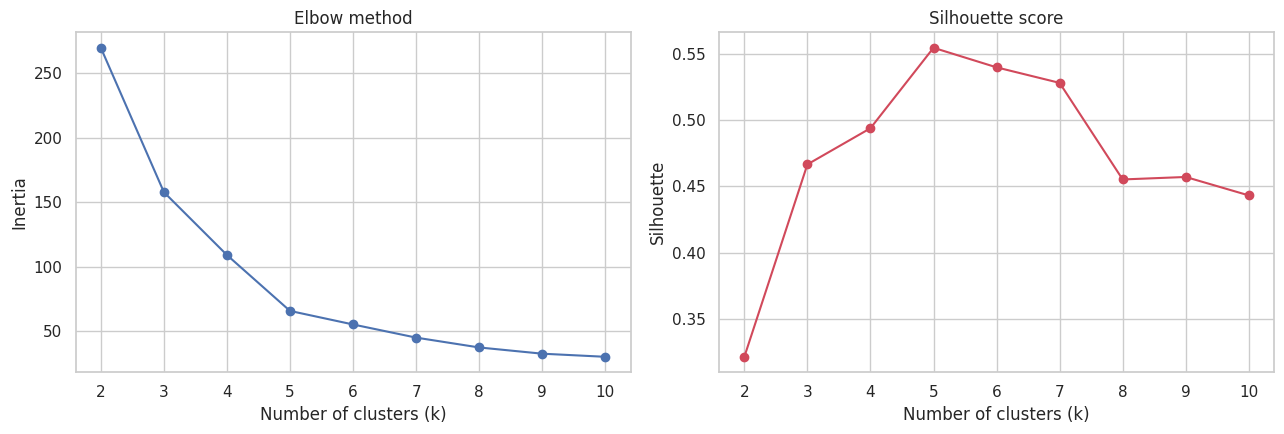

k,2,3,4,5,6,7,8,9,10
inertia,269.700,157.700,108.900,65.600,55.10,44.900,37.200,32.400,30.000
silhouette,0.321,0.467,0.494,0.555,0.54,0.528,0.455,0.457,0.443


In [7]:
ks = range(2, 11)
inertias, sils = [], []
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X)
    inertias.append(km_k.inertia_)
    sils.append(silhouette_score(X, km_k.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ks, inertias, marker="o"); ax[0].set(title="Elbow method", xlabel="Number of clusters (k)", ylabel="Inertia")
ax[1].plot(ks, sils, marker="o", color="#D1495B"); ax[1].set(title="Silhouette score", xlabel="Number of clusters (k)", ylabel="Silhouette")
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(ks), "inertia": np.round(inertias, 1), "silhouette": np.round(sils, 3)}).set_index("k").T

**Reading the plots**
- **Elbow:** inertia drops by about 43 units going from k = 4 to k = 5, but only by about 11 going from k = 5 to k = 6. The curve bends at **k = 5**.
- **Silhouette:** the highest score is at **k = 5** (0.55), with k = 6 close behind (0.54).
- Both tools point to **5 segments**, which also matches the five visible clumps in the scatter plot.

## Step 6 — Run K-Means with k = 5

**How K-Means works :**
1. Pick 5 starting centre points.
2. Assign every customer to the nearest centre.
3. Move each centre to the average of its customers.
4. Repeat steps 2–3 until nothing changes.

I use `n_init=10`, meaning the whole thing is run from 10 different random starts and the best result is kept, because a bad starting point can give a bad answer.

In [8]:
kmeans = KMeans(n_clusters=5, n_init=10, random_state=SEED)
df["cluster"] = kmeans.fit_predict(X)
df["cluster"].value_counts().sort_index()

cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

In [9]:
# Describe each cluster in the original units, and give it a readable name
profile = df.groupby("cluster").agg(customers=("income", "size"), avg_age=("Age", "mean"),
                                    avg_income=("income", "mean"), avg_score=("score", "mean"),
                                    pct_female=("Gender", lambda s: (s == "Female").mean() * 100))

def level(v, low, high):
    return "Low" if v < low else ("High" if v > high else "Average")

profile["segment"] = [f"{level(r.avg_income, 40, 70)} income, {level(r.avg_score, 35, 65).lower()} spending"
                      for r in profile.itertuples()]
name_of = profile["segment"].to_dict()
df["segment"] = df["cluster"].map(name_of)

profile.set_index("segment").sort_values("avg_income").round(1)

,customers,avg_age,avg_income,avg_score,pct_female
segment,,,,,
"Low income, high spending",22,25.3,25.7,79.4,59.1
"Low income, low spending",23,45.2,26.3,20.9,60.9
"Average income, average spending",81,42.7,55.3,49.5,59.3
"High income, high spending",39,32.7,86.5,82.1,53.8
"High income, low spending",35,41.1,88.2,17.1,45.7


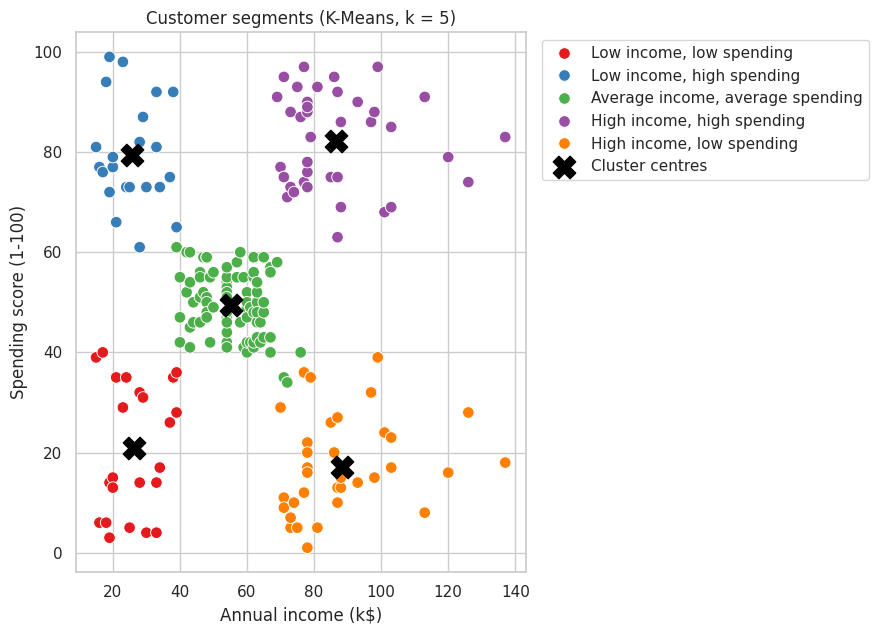

In [10]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)       # back to original units
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=df, x="income", y="score", hue="segment", palette="Set1", s=70, edgecolor="white")
plt.scatter(centers[:, 0], centers[:, 1], marker="X", s=260, c="black", label="Cluster centres")
plt.title("Customer segments (K-Means, k = 5)"); plt.xlabel("Annual income (k$)"); plt.ylabel("Spending score (1-100)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.tight_layout(); plt.show()

### The five segments

| Segment | Customers | Avg income (k$) | Avg score | Avg age |
|---|---|---|---|---|
| **High income, high spending** | 39 | 87 | 82 | 33 |
| **Low income, high spending** | 22 | 26 | 79 | 25 |
| **Average income, average spending** | 81 | 55 | 50 | 43 |
| **High income, low spending** | 35 | 88 | 17 | 41 |
| **Low income, low spending** | 23 | 26 | 21 | 45 |

**Takeaways**
- The biggest segment is the **average income, average spending** group (81 of 200 customers).
- The two **high-spending** segments are also the **youngest** (average age about 25 and 33); the other three segments average about 41–45 years.
- Gender does not separate the segments: every segment is between 46% and 61% female.

## Step 7 — From clusters to business actions

Clusters are only useful if they lead to a decision. Here is how each segment could be treated (these are suggestions to test, not proven results):

| Segment | Idea |
|---|---|
| **High income, high spending** | Most valuable group. Loyalty rewards, premium and early-access offers. |
| **Low income, high spending** | Enthusiastic spenders on a smaller budget. Discounts, bundles and reward points to keep them coming back (and watch for over-spending). |
| **High income, low spending** | Money to spend but not spending *here*. The biggest opportunity: find out why (range, experience, marketing) and target them with relevant offers. |
| **Average income, average spending** | The bulk of customers. Steady, broad-based promotions. |
| **Low income, low spending** | Price-sensitive and low engagement. Low-cost, occasional promotions; not worth heavy marketing spend. |

## Step 8 — Is the result trustworthy? Two checks

There are no true labels, so we cannot compute accuracy. Instead we check whether the result is **stable**, using the **Adjusted Rand Index (ARI)**: 1.0 means two clusterings are identical, around 0 means they agree no more than random chance.

**Check 1: different random starts.** Do we get the same segments if the random starting points change?

In [11]:
ref = kmeans.labels_
one_start = [adjusted_rand_score(ref, KMeans(5, n_init=1,  random_state=s).fit(X).labels_) for s in range(20)]
ten_start = [adjusted_rand_score(ref, KMeans(5, n_init=10, random_state=s).fit(X).labels_) for s in range(20)]

print(f"n_init = 1  (single start): ARI min = {min(one_start):.2f}, mean = {np.mean(one_start):.2f}")
print(f"n_init = 10 (best of 10)  : ARI min = {min(ten_start):.2f}, mean = {np.mean(ten_start):.2f}")

n_init = 1  (single start): ARI min = 0.69, mean = 0.95
n_init = 10 (best of 10)  : ARI min = 1.00, mean = 1.00


With a **single random start** the result sometimes changes (worst case ARI 0.69), because K-Means can get stuck in a poor solution. With **10 starts** the answer is stable (worst case ARI 1.00). That is why `n_init=10` matters.

**Check 2: a different algorithm.** Hierarchical (Ward) clustering builds groups differently, by repeatedly merging the two closest groups. If it finds the same segments, we can be more confident they are real.

Agreement between K-Means and hierarchical clustering (ARI): 0.94


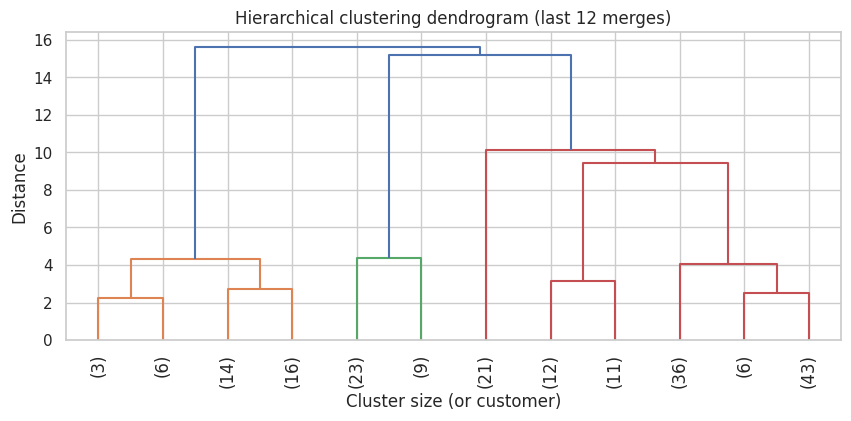

In [12]:
ward = AgglomerativeClustering(n_clusters=5, linkage="ward").fit(X)
print(f"Agreement between K-Means and hierarchical clustering (ARI): {adjusted_rand_score(ref, ward.labels_):.2f}")

plt.figure(figsize=(10, 4))
dendrogram(linkage(X, method="ward"), truncate_mode="lastp", p=12, leaf_rotation=90)
plt.title("Hierarchical clustering dendrogram (last 12 merges)"); plt.xlabel("Cluster size (or customer)"); plt.ylabel("Distance"); plt.show()

The two methods agree strongly (ARI = 0.94), so the five segments are not an artefact of K-Means. In the dendrogram, the tall vertical lines near the top are the last merges: joining groups that are far apart is what you see when real, well-separated groups exist.

## Step 9 — What if we add Age as a third feature?

In [13]:
X3 = StandardScaler().fit_transform(df[["Age", "income", "score"]])
sil_2d = silhouette_score(X, KMeans(5, n_init=10, random_state=SEED).fit(X).labels_)
sil_3d = silhouette_score(X3, KMeans(5, n_init=10, random_state=SEED).fit(X3).labels_)
print(f"Silhouette with income + score       : {sil_2d:.3f}")
print(f"Silhouette with age + income + score : {sil_3d:.3f}")

Silhouette with income + score       : 0.555
Silhouette with age + income + score : 0.417


Adding Age **lowers** the silhouette score from 0.55 to 0.42: the clusters become less distinct, because age does not form clear groups the way income and spending do. So I keep the two-feature version. Choosing which features to cluster on is a judgement call, and it should be justified like this.

## Step 10 — Assign new customers to a segment

In [14]:
new_customers = pd.DataFrame({"income": [20, 85, 60, 30], "score": [90, 15, 50, 10]})
clusters = kmeans.predict(scaler.transform(new_customers[features]))
new_customers["segment"] = [name_of[c] for c in clusters]
new_customers

,income,score,segment
0,20,90,"Low income, high spending"
1,85,15,"High income, low spending"
2,60,50,"Average income, average spending"
3,30,10,"Low income, low spending"


## Step 11 — Conclusions & limitations

**Conclusions**
- Customers fall into **5 clear segments** based on income and spending score. The elbow method and silhouette score both chose k = 5 (silhouette 0.55).
- The result is **stable**: it does not depend on the random starting points when `n_init=10` is used, and a different algorithm (hierarchical) finds almost the same groups (ARI 0.94).
- The most interesting groups for marketing are **high income, low spending** (untapped potential) and **high income, high spending** (most valuable).

**Limitations (say these in an interview)**
- Clustering has **no ground truth**. The number of clusters and the segment names are judgement calls supported by metrics, not facts.
- Only 200 customers and two behaviour features; the "spending score" is defined by the mall and is not explained, and the dataset is a teaching dataset of unclear origin.
- K-Means assumes roughly round, similarly sized clusters and is sensitive to scaling and to the choice of k.
- Segments describe customers; they do not prove *why* they behave that way. To check that a segment-specific offer works, you would run an **A/B test**.

---
# 🎤 Interview cheat sheet

## 60-second pitch
> "I did a customer segmentation project on 200 mall customers using K-Means clustering. Clustering is unsupervised, so there are no labels. I standardised income and spending score so neither dominates the distance, and chose the number of clusters using the elbow method and the silhouette score; both pointed to five. I then profiled each segment, for example a high-income, low-spending group that looks like the biggest marketing opportunity, and suggested a different action for each. To check the result I ran K-Means from many random starts and compared it with hierarchical clustering; the two agreed strongly (ARI 0.94). I also found that adding age made the clusters less distinct, so I left it out."

## Likely questions & simple answers

**What is clustering? How is it different from classification?**
Clustering is unsupervised: there are no labels, and the algorithm finds groups of similar items. Classification is supervised: we predict a known label.

**Explain K-Means in a few lines.**
Pick k centres, assign each point to its nearest centre, move each centre to the mean of its points, and repeat until nothing changes.

**Why did you scale the data?**
K-Means uses distances. A feature with larger numbers would dominate, so I standardised everything to the same scale.

**How did you choose k = 5?**
The elbow method (inertia stops falling much after 5) and the silhouette score (highest at 5), plus it matched the visible clumps. I treated it as a judgement supported by two metrics.

**What is inertia? What is the silhouette score?**
Inertia is the total squared distance from points to their cluster centre; lower is tighter. Silhouette measures how much closer a point is to its own cluster than to the nearest other one, from −1 to 1; higher is better.

**There are no labels, so how do you know the clusters are good?**
I can't measure accuracy. I checked stability (different random starts, ARI), agreement with a different algorithm (hierarchical, ARI 0.94), and whether the segments make business sense.

**What does `n_init` do?**
It runs K-Means from several random starts and keeps the best. With a single start the result sometimes changed (worst-case ARI 0.69); with 10 it was stable.

**Why didn't you include Age or Gender?**
I tested Age: it lowered the silhouette from 0.55 to 0.42, meaning blurrier clusters. Gender is categorical, which K-Means (distance-based) doesn't handle well, and it did not differ across the segments anyway.

**What are the limitations of K-Means?**
You must choose k, it is sensitive to scaling and outliers, and it assumes round, similar-sized clusters.

**What would you do with these segments?**
Use a different marketing action per segment and run an A/B test to confirm the offers work.

**Where did the data come from?**
Be upfront: *"It's a public practice dataset, widely used for segmentation tutorials, with undocumented origins. I treated it as a learning dataset."*